# Forward Stepwise Selection for Phishing URL Classification
target encoding: **1 = legitimate**, **0 = phishing**.


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
import matplotlib.pyplot as plt


In [2]:
df_train = pd.read_csv("../data/processed/train_lin.csv")
df_test = pd.read_csv("../data/processed/test_lin.csv")

In [3]:
def forward_stepwise_selection(X, y, p_enter=0.01, max_features=None, verbose=True):
    """
    Forward stepwise feature selection using p-values from statsmodels Logit.
    Stops when no remaining feature has p-value < p_enter.
    """
    selected = []
    remaining = list(X.columns)
    history = []

    if max_features is None:
        max_features = len(remaining)

    for step in range(max_features):
        best_feature = None
        best_p = np.inf
        best_model = None

        for feature in remaining:
            trial_features = selected + [feature]
            X_trial = sm.add_constant(X[trial_features], has_constant='add')
            try:
                model = sm.Logit(y, X_trial).fit(disp=0, method='lbfgs', maxiter=200)
                pval = model.pvalues.get(feature, np.inf)
            except Exception:
                continue

            if pval < best_p:
                best_p = pval
                best_feature = feature
                best_model = model

        if best_feature is None or best_p >= p_enter:
            if verbose:
                print(f'Stopping at step {step+1}: no feature met p < {p_enter}.')
            break

        selected.append(best_feature)
        remaining.remove(best_feature)
        history.append({
            'step': step + 1,
            'feature': best_feature,
            'p_value': float(best_p),
            'aic': float(best_model.aic),
            'bic': float(best_model.bic),
            'pseudo_r2': float(best_model.prsquared),
        })

        if verbose:
            print(f"Step {step+1}: added '{best_feature}' (p={best_p:.3e}, AIC={best_model.aic:.2f})")

    history_df = pd.DataFrame(history)
    return selected, history_df


In [4]:
X_train = df_train.drop(columns=['label'])
y_train = df_train['label'].astype(int)

X_test = df_test.drop(columns=['label'])
y_test = df_test['label'].astype(int)

# Forward stepwise selection (stricter p-value to keep model compact)
selected_features, selection_history = forward_stepwise_selection(
    X_train, y_train, p_enter=0.01, max_features=40, verbose=True
)

if len(selected_features) == 0:
    raise RuntimeError('No features were selected. Try a larger p_enter (e.g., 0.05).')

print(f'\nTotal selected features: {len(selected_features)}')
print(selected_features)
#print('Was URLSimilarityIndex selected?:', 'URLSimilarityIndex' in selected_features)
display(selection_history)

X_train_sel = sm.add_constant(X_train[selected_features], has_constant='add')
final_model = sm.Logit(y_train, X_train_sel).fit(disp=0, method='lbfgs', maxiter=300)
print(final_model.summary())


c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


Step 1: added 'URLLength' (p=0.000e+00, AIC=205642.12)


c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\L

Step 2: added 'DomainLength' (p=0.000e+00, AIC=197670.32)


c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\L

...

Stopping at step 14: no feature met p < 0.01.

Total selected features: 13
['URLLength', 'DomainLength', 'CharContinuationRate', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'NoOfLettersInURL', 'NoOfDegitsInURL', 'LetterRatioInURL', 'DegitRatioInURL', 'SpacialCharRatioInURL', 'TLD_phishing_rate', 'NoOfOtherSpecialCharsInURL']


,step,feature,p_value,aic,bic,pseudo_r2
0,1,URLLength,0.000000e+00,205642.118022,205662.413171,0.201688
1,2,DomainLength,0.000000e+00,197670.323904,197700.766627,0.232644
2,3,CharContinuationRate,0.000000e+00,182046.233115,182086.823413,0.293306
3,4,URLCharProb,0.000000e+00,165465.934633,165516.672505,0.357680
4,5,TLDLength,0.000000e+00,160831.110921,160891.996368,0.375681
5,6,NoOfSubDomain,0.000000e+00,156351.694746,156422.727768,0.393079
6,7,NoOfLettersInURL,0.000000e+00,147008.892471,147090.073067,0.429356
7,8,NoOfDegitsInURL,0.000000e+00,58215.380982,58306.709152,0.774071
8,9,LetterRatioInURL,0.000000e+00,56319.226561,56420.702307,0.781440
9,10,DegitRatioInURL,0.000000e+00,52330.992820,52442.616140,0.796930


c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


                           Logit Regression Results                           
Dep. Variable:                  label   No. Observations:               188636
Model:                          Logit   Df Residuals:                   188622
Method:                           MLE   Df Model:                           13
Date:                Thu, 02 Apr 2026   Pseudo R-squ.:                  0.9852
Time:                        15:53:40   Log-Likelihood:                -1907.5
converged:                       True   LL-Null:                   -1.2880e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                        -77.8207      4.330    -17.971      0.000     -86.308     -69.333
URLLength                    701.4140     63.205     11.097      0.000     577.534 

c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


Test metrics (positive class = legitimate URL, label=1):
Accuracy : 0.9979
Precision: 0.9966
Recall   : 0.9997
F1-score : 0.9981
ROC-AUC  : 0.9990

Classification report:
                precision    recall  f1-score   support

  phishing (0)       1.00      1.00      1.00     20189
legitimate (1)       1.00      1.00      1.00     26970

      accuracy                           1.00     47159
     macro avg       1.00      1.00      1.00     47159
  weighted avg       1.00      1.00      1.00     47159

Confusion matrix [[TN, FP], [FN, TP]]:
[[20098    91]
 [    9 26961]]


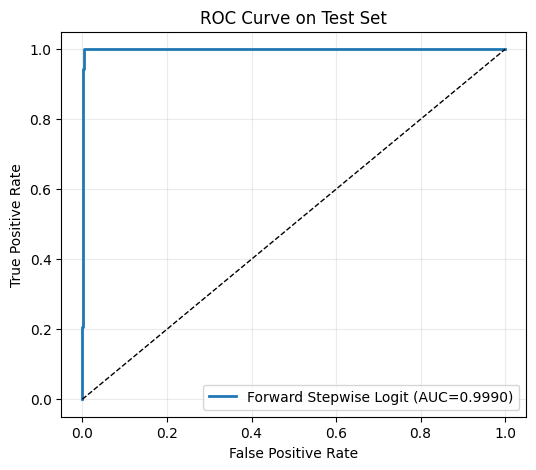

In [5]:
X_test_sel = sm.add_constant(X_test[selected_features], has_constant='add')
y_prob = final_model.predict(X_test_sel)
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)

print('Test metrics (positive class = legitimate URL, label=1):')
print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1-score : {f1:.4f}')
print(f'ROC-AUC  : {auc:.4f}')

print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['phishing (0)', 'legitimate (1)']))

cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix [[TN, FP], [FN, TP]]:')
print(cm)

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Forward Stepwise Logit (AUC={auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set')
plt.legend(loc='lower right')
plt.grid(alpha=0.25)
plt.show()


# Backward Stepwise Selection for Phishing URL Classification
target encoding: **1 = legitimate**, **0 = phishing**.

In [5]:
def backward_stepwise_selection(X, y, p_remove=0.05, min_features=1, verbose=True):
    """
    Backward stepwise feature selection for statsmodels Logit.

    Primary rule:
    - Remove feature with highest p-value if that p-value > p_remove.

    Fallback rule (when p-values are all NaN due to Hessian/covariance issues):
    - Try one-feature removal candidates and remove the feature that gives the
      best AIC only if AIC improves.
    """
    selected = list(X.columns)
    history = []

    while len(selected) > min_features:
        X_curr = sm.add_constant(X[selected], has_constant='add')
        try:
            model = sm.Logit(y, X_curr).fit(disp=0, method='lbfgs', maxiter=300)
        except Exception as e:
            if verbose:
                print(f'Stopped: model fitting failed with current feature set ({len(selected)} features).')
                print('Reason:', str(e))
            break

        pvals = model.pvalues.drop(labels='const', errors='ignore').dropna()

        # Standard p-value elimination path.
        if not pvals.empty:
            worst_feature = pvals.idxmax()
            worst_p = float(pvals.max())

            if worst_p <= p_remove:
                if verbose:
                    print(f"Stopping: all remaining features have p <= {p_remove}.")
                break

            selected.remove(worst_feature)
            history.append({
                'step': len(history) + 1,
                'removed_feature': worst_feature,
                'removed_p_value': float(worst_p),
                'criterion': 'p_value',
                'aic_before_removal': float(model.aic),
                'bic_before_removal': float(model.bic),
                'pseudo_r2_before_removal': float(model.prsquared),
                'remaining_features': len(selected),
            })

            if verbose:
                print(f"Step {len(history)}: removed '{worst_feature}' (p={worst_p:.3e}), remaining={len(selected)}")
            continue

        # Fallback: if p-values are all NaN, use AIC improvement to decide removal.
        current_aic = float(model.aic)
        best_feature = None
        best_aic = np.inf

        for feature in list(selected):
            trial_features = [f for f in selected if f != feature]
            X_trial = sm.add_constant(X[trial_features], has_constant='add')
            try:
                trial_model = sm.Logit(y, X_trial).fit(disp=0, method='lbfgs', maxiter=300)
                if trial_model.aic < best_aic:
                    best_aic = float(trial_model.aic)
                    best_feature = feature
            except Exception:
                continue

        if best_feature is not None and best_aic < current_aic:
            selected.remove(best_feature)
            history.append({
                'step': len(history) + 1,
                'removed_feature': best_feature,
                'removed_p_value': np.nan,
                'criterion': 'aic_fallback',
                'aic_before_removal': current_aic,
                'bic_before_removal': float(model.bic),
                'pseudo_r2_before_removal': float(model.prsquared),
                'remaining_features': len(selected),
            })

            if verbose:
                print(
                    f"Step {len(history)}: removed '{best_feature}' via AIC fallback "
                    f"(AIC {current_aic:.2f} -> {best_aic:.2f}), remaining={len(selected)}"
                )
        else:
            if verbose:
                print('Stopping: no valid p-values and no AIC-improving single-feature removal found.')
            break

    history_df = pd.DataFrame(history)
    return selected, history_df



In [6]:
# Use the same train/test split already loaded above
X_train_bw = df_train.drop(columns=['label'])
y_train_bw = df_train['label'].astype(int)

X_test_bw = df_test.drop(columns=['label'])
y_test_bw = df_test['label'].astype(int)

selected_features_bw, elimination_history = backward_stepwise_selection(
    X_train_bw, y_train_bw, p_remove=0.05, min_features=1, verbose=True
)

if len(selected_features_bw) == 0:
    raise RuntimeError('No features remained after backward selection. Try a larger p_remove.')

print(f'\nTotal remaining features: {len(selected_features_bw)}')
print(selected_features_bw)
display(elimination_history)

X_train_sel_bw = sm.add_constant(X_train_bw[selected_features_bw], has_constant='add')
final_model_bw = sm.Logit(y_train_bw, X_train_sel_bw).fit(disp=0, method='lbfgs', maxiter=300)
print(final_model_bw.summary())


c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discr

Step 1: removed 'IsHTTPS' via AIC fallback (AIC 4049.71 -> 3861.03), remaining=22


c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\

Step 2: removed 'TLD_freq' via AIC fallback (AIC 3861.03 -> 3855.55), remaining=21


c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\

...

Stopping: all remaining features have p <= 0.05.

Total remaining features: 11
['URLLength', 'CharContinuationRate', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'NoOfLettersInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'TLD_phishing_rate']


,step,removed_feature,removed_p_value,criterion,aic_before_removal,bic_before_removal,pseudo_r2_before_removal,remaining_features
0,1,IsHTTPS,NaN,aic_fallback,4049.713474,4293.255262,0.984465,22
1,2,TLD_freq,NaN,aic_fallback,3861.034635,4094.428849,0.985190,21
2,3,LetterRatioInURL,NaN,aic_fallback,3855.551693,4078.798332,0.985203,20
3,4,HasObfuscation,NaN,aic_fallback,3847.871083,4060.970147,0.985225,19
4,5,NoOfEqualsInURL,NaN,aic_fallback,3845.798325,4048.749815,0.985225,18
5,6,NoOfQMarkInURL,NaN,aic_fallback,3843.737268,4036.541183,0.985226,17
6,7,NoOfObfuscatedChar,NaN,aic_fallback,3841.940682,4024.597023,0.985225,16
7,8,TLDLegitimateProb,NaN,aic_fallback,3839.717635,4012.226402,0.985226,15
8,9,IsDomainIP,NaN,aic_fallback,3838.057081,4000.418273,0.985224,14
9,10,NoOfAmpersandInURL,1.000000,p_value,3835.973606,3988.187224,0.985225,13


c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


                           Logit Regression Results                           
Dep. Variable:                  label   No. Observations:               188636
Model:                          Logit   Df Residuals:                   188624
Method:                           MLE   Df Model:                           11
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                  0.9364
Time:                        16:31:07   Log-Likelihood:                -8190.6
converged:                       True   LL-Null:                   -1.2880e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                        -15.2767      0.181    -84.516      0.000     -15.631     -14.922
URLLength                    359.4662      2.603    138.075      0.000     354.364 

c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


Test metrics (positive class = legitimate URL, label=1):
Accuracy : 0.9931
Precision: 0.9924
Recall   : 0.9956
F1-score : 0.9940
ROC-AUC  : 0.9974

Classification report:
                precision    recall  f1-score   support

  phishing (0)       0.99      0.99      0.99     20189
legitimate (1)       0.99      1.00      0.99     26970

      accuracy                           0.99     47159
     macro avg       0.99      0.99      0.99     47159
  weighted avg       0.99      0.99      0.99     47159

Confusion matrix [[TN, FP], [FN, TP]]:
[[19983   206]
 [  119 26851]]


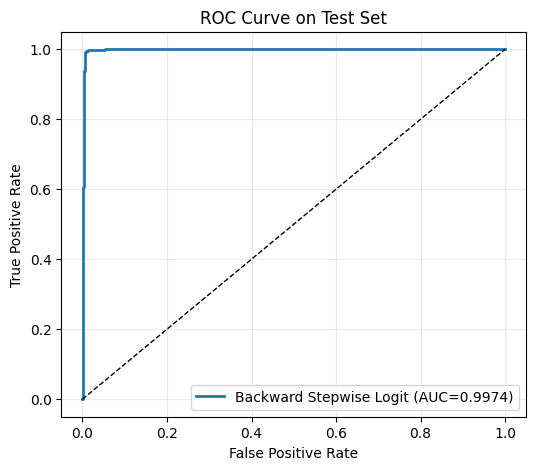

In [7]:
X_test_sel_bw = sm.add_constant(X_test_bw[selected_features_bw], has_constant='add')
y_prob_bw = final_model_bw.predict(X_test_sel_bw)
y_pred_bw = (y_prob_bw >= 0.5).astype(int)

acc_bw = accuracy_score(y_test_bw, y_pred_bw)
prec_bw = precision_score(y_test_bw, y_pred_bw, zero_division=0)
rec_bw = recall_score(y_test_bw, y_pred_bw, zero_division=0)
f1_bw = f1_score(y_test_bw, y_pred_bw, zero_division=0)
auc_bw = roc_auc_score(y_test_bw, y_prob_bw)

print('Test metrics (positive class = legitimate URL, label=1):')
print(f'Accuracy : {acc_bw:.4f}')
print(f'Precision: {prec_bw:.4f}')
print(f'Recall   : {rec_bw:.4f}')
print(f'F1-score : {f1_bw:.4f}')
print(f'ROC-AUC  : {auc_bw:.4f}')

print('\nClassification report:')
print(classification_report(y_test_bw, y_pred_bw, target_names=['phishing (0)', 'legitimate (1)']))

cm_bw = confusion_matrix(y_test_bw, y_pred_bw)
print('Confusion matrix [[TN, FP], [FN, TP]]:')
print(cm_bw)

fpr_bw, tpr_bw, _ = roc_curve(y_test_bw, y_prob_bw)
plt.figure(figsize=(6, 5))
plt.plot(fpr_bw, tpr_bw, label=f'Backward Stepwise Logit (AUC={auc_bw:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set')
plt.legend(loc='lower right')
plt.grid(alpha=0.25)
plt.show()
